使用5分K、日盤資料

In [1]:
import pandas as pd

df = pd.read_csv(f"TXF_1T_20240415.csv", index_col=0)
df.index = pd.to_datetime(df.index)

df = df.resample('1T', label='right', closed='right').agg(
    {'Open'  :'first',
     'High'  :'max',
     'Low'   :'min',
     'Close' :'last',
     'Volume':'sum',
     '大戶買進' :'sum',
     '散戶買進' :'sum',
     '大戶掛單' :'sum',
     '散戶掛單' :'sum'
    })

df = df.fillna(method='ffill')
#df= df.between_time('08:44:59', '13:45:01') #日盤
#df= df.between_time('14:59:59', '05:00:01') #夜盤
df = pd.concat([df.between_time('14:59:59', '05:00:01'), df.between_time('08:44:59', '13:45:01')]).sort_index() #日盤+夜盤
df

,Open,High,Low,Close,Volume,大戶買進,散戶買進,大戶掛單,散戶掛單
2020-03-22 08:46:00,9041.0,9050.0,9036.0,9037.0,889.0,0.0,3.0,0.0,75.045455
2020-03-22 08:47:00,9044.0,9049.0,9035.0,9042.0,422.0,35.0,6.0,0.0,226.470588
2020-03-22 08:48:00,9048.0,9050.0,9035.0,9049.0,85.0,42.0,11.0,0.0,550.666667
2020-03-22 08:49:00,9040.0,9050.0,9035.0,9035.0,473.0,63.0,11.0,0.0,836.555556
2020-03-22 08:50:00,9041.0,9059.0,9037.0,9044.0,301.0,77.0,11.0,0.0,1211.416667
...,...,...,...,...,...,...,...,...,...
2024-04-13 04:56:00,20500.0,20501.0,20499.0,20500.0,36.0,-210.0,-4316.0,10.0,8425.105263
2024-04-13 04:57:00,20499.0,20499.0,20497.0,20498.0,25.0,-210.0,-4315.0,0.0,8427.357143
2024-04-13 04:58:00,20496.0,20498.0,20492.0,20495.0,116.0,-210.0,-4352.0,0.0,8455.554054
2024-04-13 04:59:00,20494.0,20495.0,20489.0,20491.0,81.0,-210.0,-4353.0,-1.0,8484.132075


In [2]:
from backtesting import Strategy
from backtesting.lib import crossover
import talib as ta
from datetime import time
from backtesting import Backtest

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
from matplotlib.ticker import StrMethodFormatter
from backtesting.lib import _EQUITY_AGG

def figure(strategy):   

    equity_data = strategy._equity_curve.resample('1D', label='right').agg(_EQUITY_AGG).dropna(how='all')
    equity_data['DrawdownPct'] = equity_data['DrawdownPct'].multiply(-100)

    f, (ax1, ax2) = plt.subplots(2, sharex=True, figsize=(19.2, 10.8), gridspec_kw={'height_ratios': [5, 2]})

    ax1.grid(linestyle = '--', linewidth = 1)
    ax1.plot(equity_data['Equity'])
    ax1.set(ylabel="Equity($)")
    ax1.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
    date_form = DateFormatter("%Y-%m-%d")
    ax1.xaxis.set_major_formatter(date_form)
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax2.grid(linestyle = '--', linewidth = 1)
    ax2.plot(equity_data['DrawdownPct'], color="red")
    ax2.set(ylabel="DrawdownPct(%)")
    ax2.fill_between(equity_data['DrawdownPct'].index, equity_data['DrawdownPct'], where=(equity_data['DrawdownPct'] <= 0), color="red")   
    f.subplots_adjust(hspace=0)
    f.autofmt_xdate()
    plt.show()

日盤多單策略

In [5]:
class MyStrategy(Strategy):
    #MACD
    fast = 5
    slow = 45
    signal = 35
    # EMA Day long
    d_big_long = 5
    d_little_long = 15
    #止損
    stop_pct = 5   #表示0.5%

    def init(self):
        self.macd, self.signal, self.hist = self.I(ta.MACD, self.data.Close, fastperiod=self.fast, slowperiod=self.slow, signalperiod=self.signal)
        self.EMA_B=self.I(ta.EMA, self.data.大戶買進, timeperiod = self.d_big_long)
        self.EMA_L=self.I(ta.EMA, self.data.散戶買進, timeperiod = self.d_little_long)
        
    def next(self):
        current_time = self.data.index[-1].time()
        if (current_time >= time(9, 15)) and (current_time <= time(13, 15)):
            if (not self.position.is_long):
                if self.hist[-1] > 0 and crossover(self.EMA_B, self.EMA_L):
                    self.buy(size=200)
            
            elif (self.position.is_long):    
                if self.hist[-1] < 0 and crossover(self.EMA_L, self.EMA_B):
                    self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
                        
        if self.position and current_time >= time(13, 15):
            self.position.close()

Start                     2020-03-22 08:46:00
End                       2024-04-13 05:00:00
Duration                   1482 days 20:14:00
Exposure Time [%]                    1.862381
Equity Final [$]                     288114.2
Equity Peak [$]                     543271.25
Return [%]                          -42.37716
Buy & Hold Return [%]              126.756667
Return (Ann.) [%]                   -12.67942
Volatility (Ann.) [%]               28.947004
Sharpe Ratio                              0.0
Sortino Ratio                             0.0
Calmar Ratio                              0.0
Max. Drawdown [%]                  -59.162564
Avg. Drawdown [%]                   -5.847073
Max. Drawdown Duration     1326 days 18:54:00
Avg. Drawdown Duration       98 days 18:54:00
# Trades                                  323
Win Rate [%]                        40.247678
Best Trade [%]                       1.828497
Worst Trade [%]                     -0.945627
Avg. Trade [%]                    

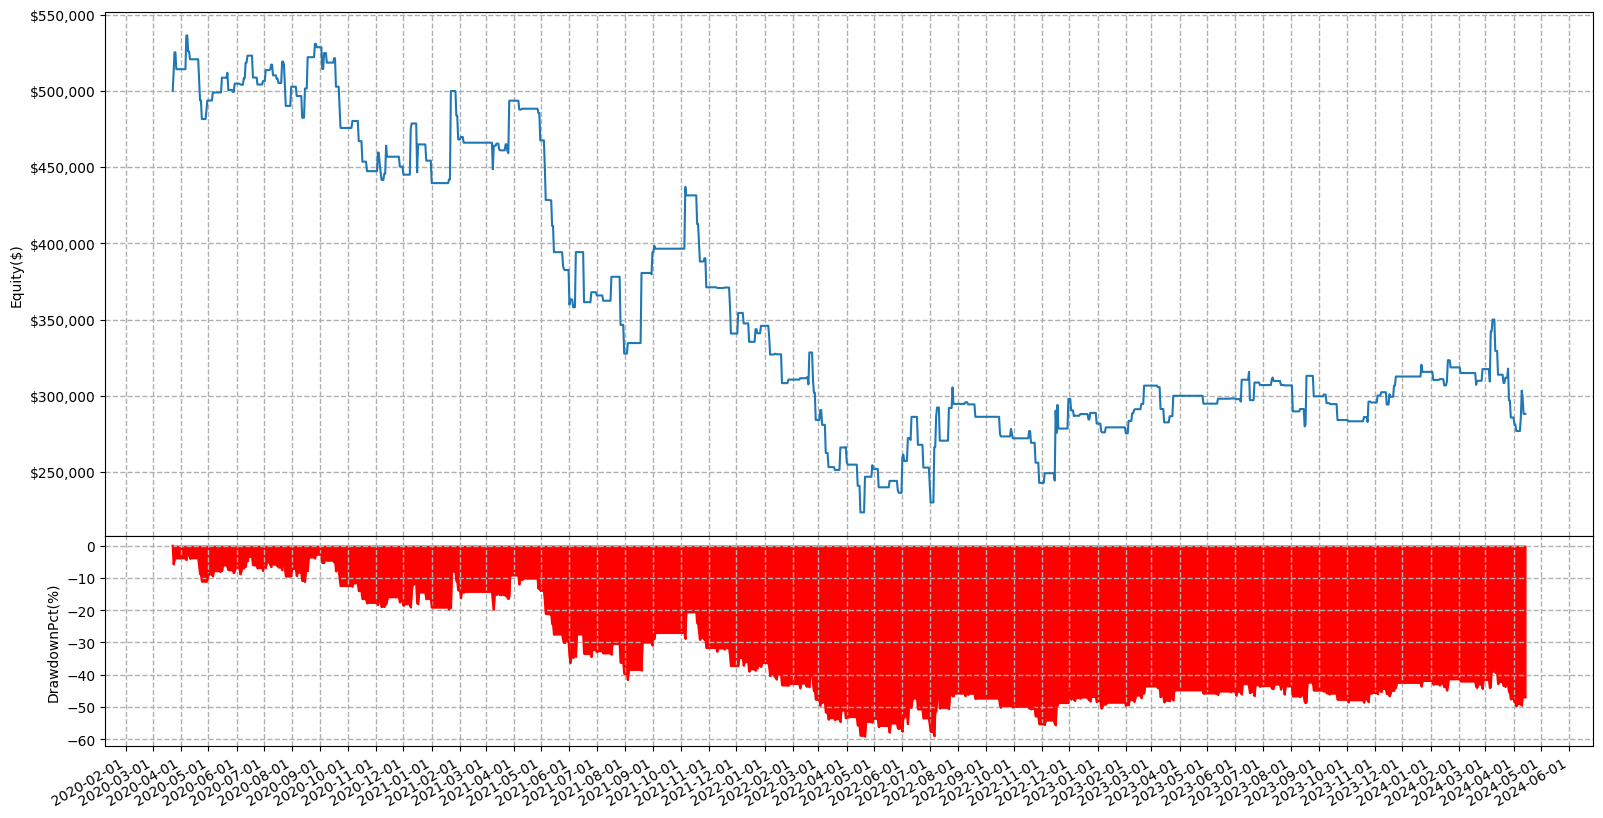

In [4]:
bt = Backtest(df, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
#Backtest(資料名稱, 策略名稱, cash=初始資金, commission=交易成本, hedging=是否優先對之前操作進行抵銷(競賽限定一次只能持有一口), exclusive_orders=每筆新交易是否關閉上一次的交易, margin=初始保證金比例)
stats = bt.run()
print(stats)
figure(stats)

  0%|          | 0/16 [00:00<?, ?it/s]

Start                     2020-03-22 08:50:00
End                       2022-12-31 23:55:00
Duration                   1014 days 15:05:00
Exposure Time [%]                    2.121789
Equity Final [$]                    727718.75
Equity Peak [$]                      794960.8
Return [%]                           45.54375
Buy & Hold Return [%]               55.860239
Return (Ann.) [%]                   14.449381
Volatility (Ann.) [%]               21.697521
Sharpe Ratio                         0.665946
Sortino Ratio                        1.318967
Calmar Ratio                         0.626359
Max. Drawdown [%]                  -23.068853
Avg. Drawdown [%]                   -1.750309
Max. Drawdown Duration      474 days 01:05:00
Avg. Drawdown Duration       13 days 21:08:00
# Trades                                  177
Win Rate [%]                        50.847458
Best Trade [%]                       1.707836
Worst Trade [%]                     -0.957028
Avg. Trade [%]                    

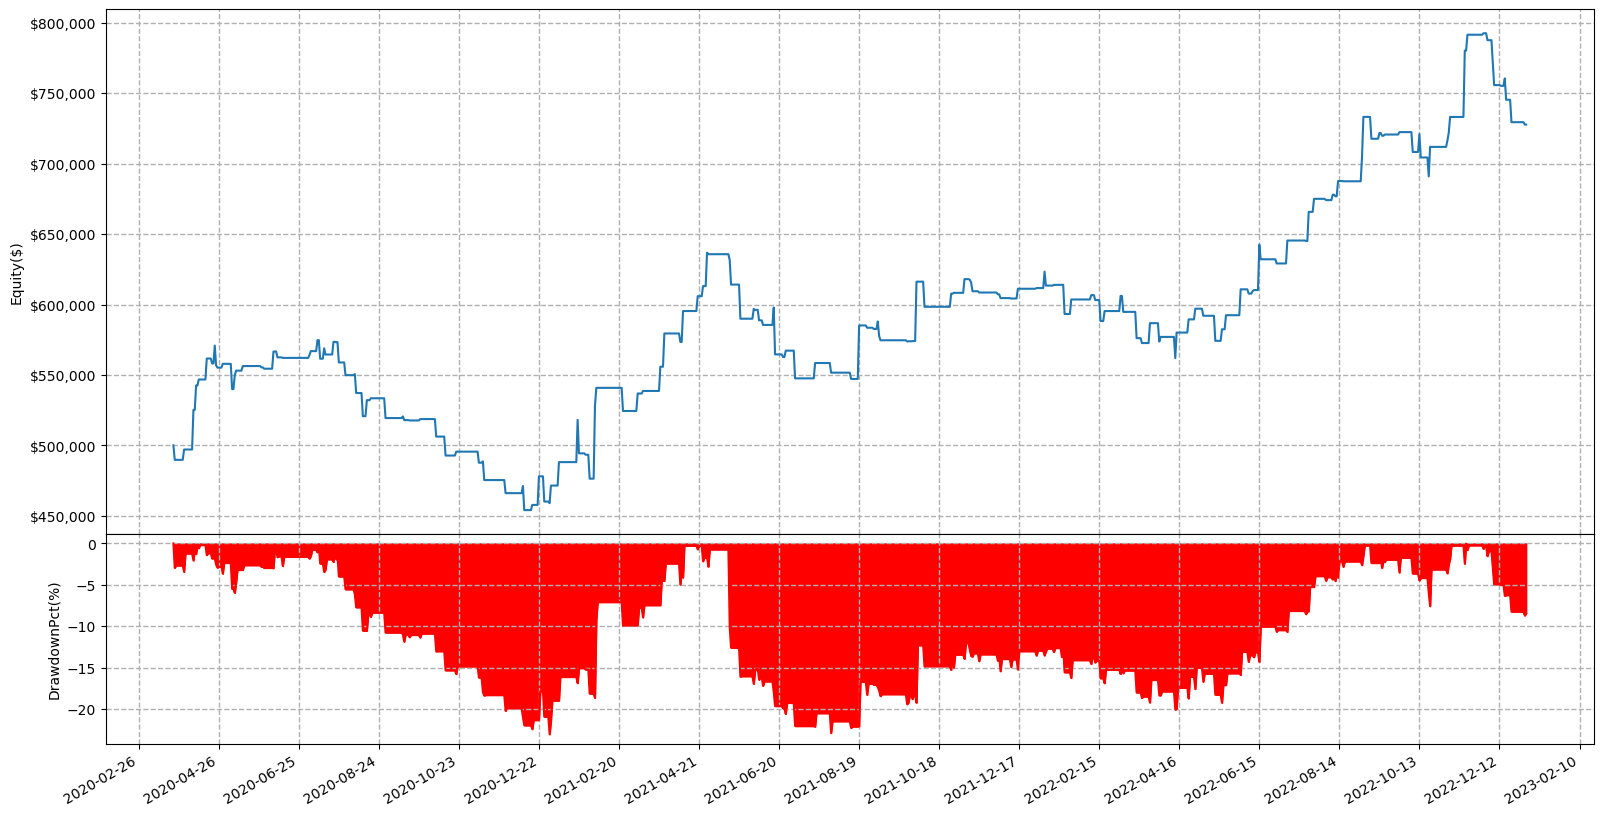

In [192]:
df_inner=df[df.index.year<2023] #樣本內2020-2022
bt_op = Backtest(df_inner, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
stats_op = bt_op.optimize(d_big_long=range(5,16,1), d_little_long=range(5,21,1))
print(stats_op)
print(stats_op['_strategy'])
figure(stats_op)

日盤空單策略

In [23]:
class MyStrategy(Strategy):

    # Williams' %R
    wl_period = 3
    # EMA day short
    d_big_short = 5
    d_little_short = 13
    # 止損
    stop_pct = 5   #表示0.5%

    def init(self):
        self.WILLR = self.I(ta.WILLR, self.data.High, self.data.Low, self.data.Close, timeperiod = self.wl_period)
        self.EMA_B = self.I(ta.EMA, self.data.大戶買進, timeperiod = self.d_big_short)
        self.EMA_L = self.I(ta.EMA, self.data.散戶買進, timeperiod = self.d_little_short)

    def next(self):
        current_time = self.data.index[-1].time()
        if (current_time >= time(9, 15)) and (current_time <= time(13, 15)):
            if (not self.position.is_short):
                if self.WILLR[-1] < -80 and crossover(self.EMA_B, self.EMA_L):
                    self.sell(size=200)
            
            elif (self.position.is_short):    
                if crossover(self.EMA_L, self.EMA_B):
                    self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()        
        if self.position and (current_time >= time(13, 15) and current_time <= time(13, 45)):
            self.position.close()

Start                     2020-03-22 08:50:00
End                       2024-04-13 05:00:00
Duration                   1482 days 20:10:00
Exposure Time [%]                    0.387582
Equity Final [$]                    682441.55
Equity Peak [$]                     712673.75
Return [%]                           36.48831
Buy & Hold Return [%]              126.581159
Return (Ann.) [%]                    7.951245
Volatility (Ann.) [%]                9.780757
Sharpe Ratio                         0.812948
Sortino Ratio                        2.176001
Calmar Ratio                         0.727698
Max. Drawdown [%]                  -10.926576
Avg. Drawdown [%]                   -1.549629
Max. Drawdown Duration      268 days 00:20:00
Avg. Drawdown Duration       36 days 13:09:00
# Trades                                   61
Win Rate [%]                        54.098361
Best Trade [%]                       1.595824
Worst Trade [%]                     -0.586494
Avg. Trade [%]                    

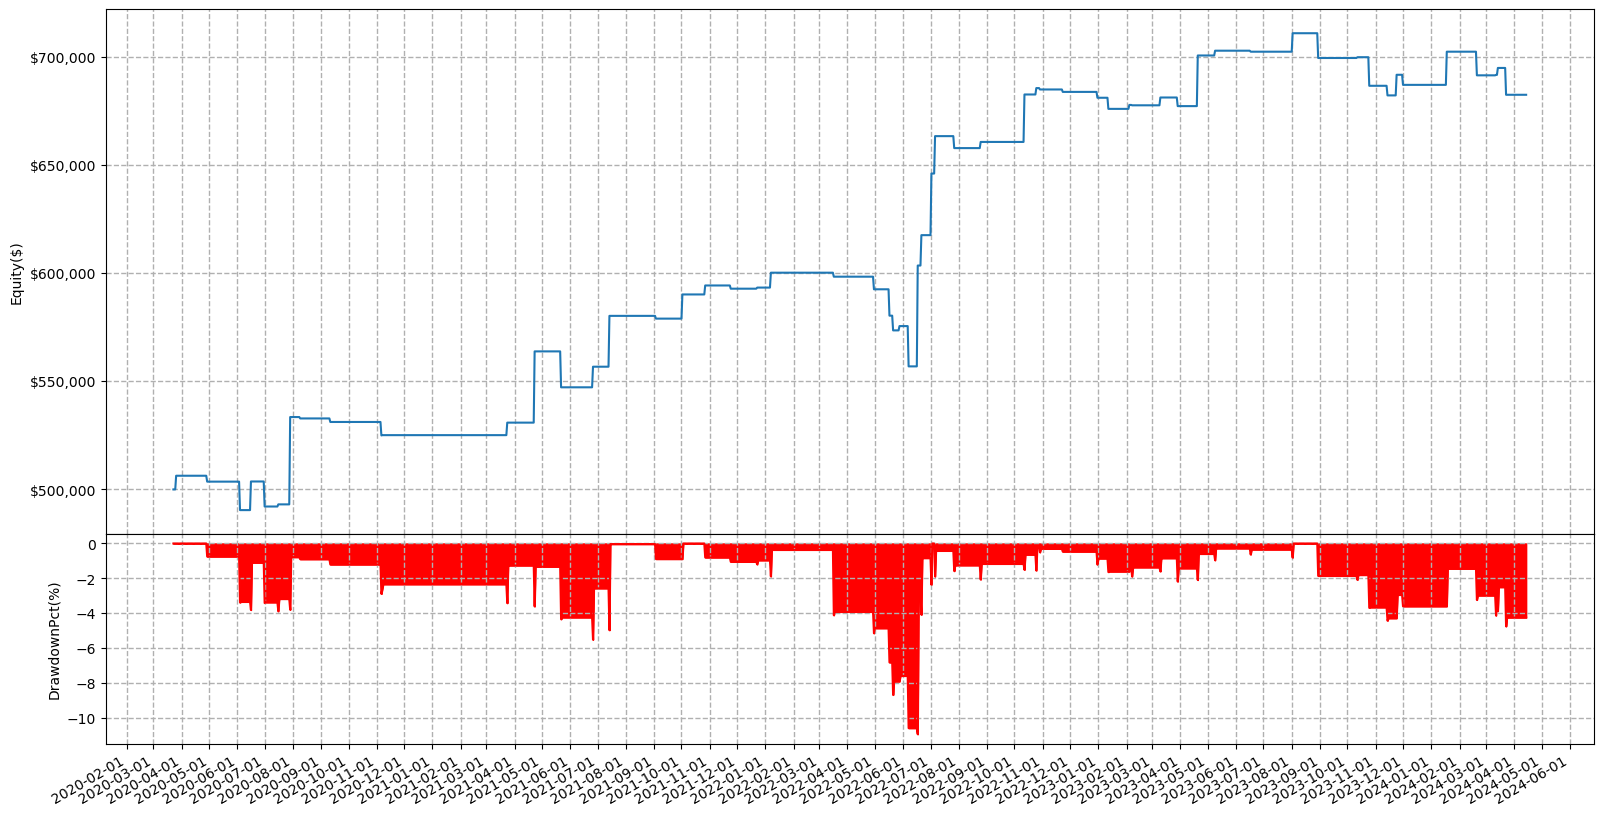

In [24]:
bt = Backtest(df, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
stats = bt.run()
print(stats)
figure(stats)

c:\Users\vince\anaconda3\lib\site-packages\backtesting\backtesting.py:1488: UserWarning: Searching for best of 528 configurations.
  output = _optimize_grid()


  0%|          | 0/16 [00:00<?, ?it/s]

Start                     2020-03-22 08:50:00
End                       2022-12-31 23:55:00
Duration                   1014 days 15:05:00
Exposure Time [%]                    0.364629
Equity Final [$]                     681065.8
Equity Peak [$]                     686978.65
Return [%]                           36.21316
Buy & Hold Return [%]               55.860239
Return (Ann.) [%]                   11.754745
Volatility (Ann.) [%]               11.591714
Sharpe Ratio                         1.014064
Sortino Ratio                        3.071438
Calmar Ratio                         1.075794
Max. Drawdown [%]                  -10.926576
Avg. Drawdown [%]                   -1.841532
Max. Drawdown Duration      268 days 00:20:00
Avg. Drawdown Duration       33 days 21:11:00
# Trades                                   40
Win Rate [%]                             55.0
Best Trade [%]                       1.595824
Worst Trade [%]                     -0.586494
Avg. Trade [%]                    

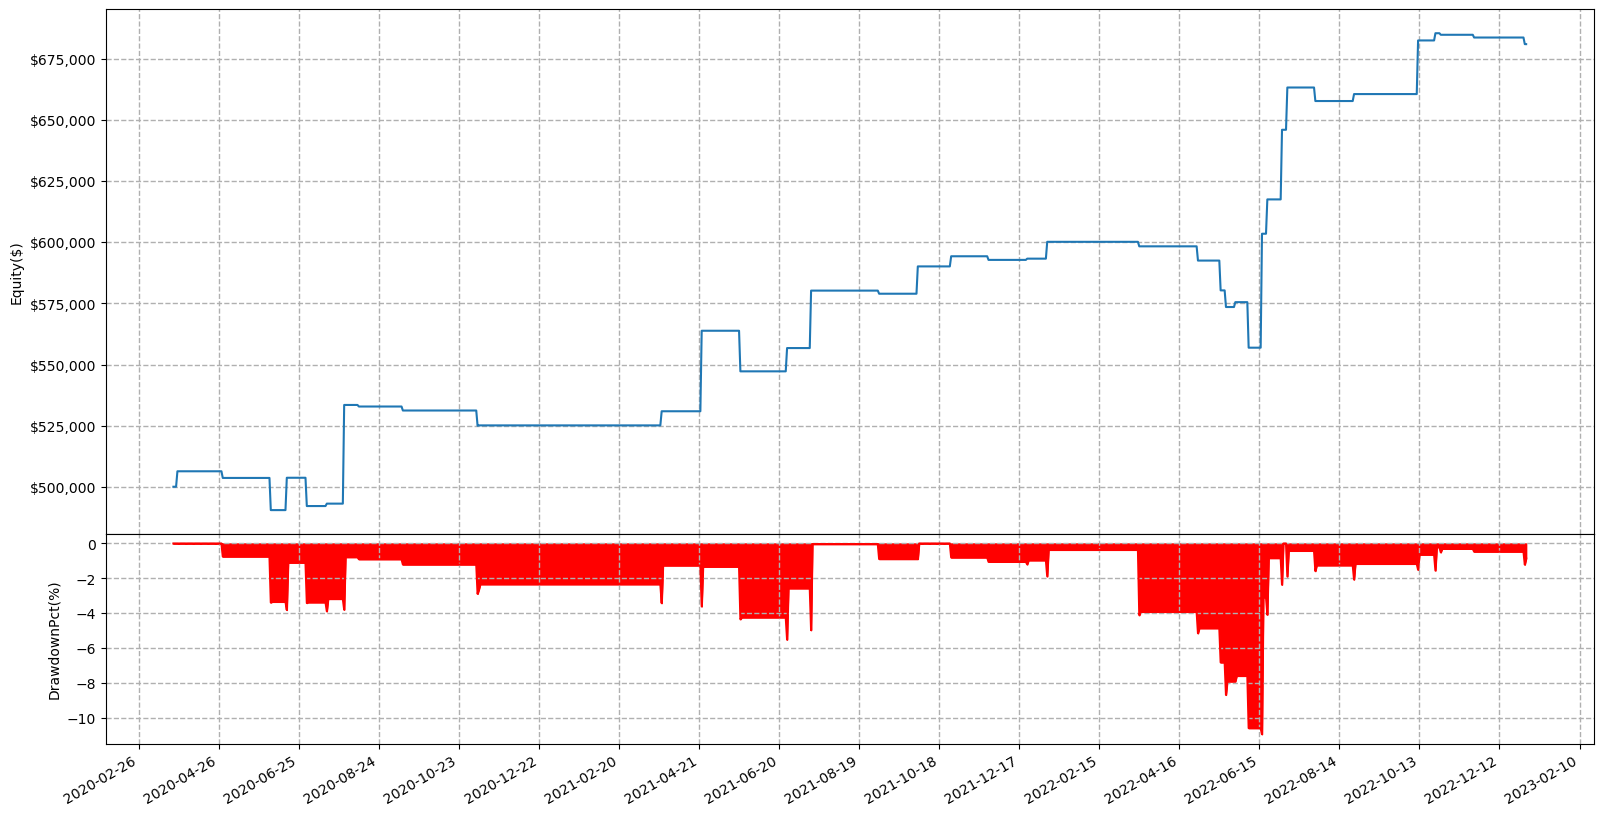

In [183]:
df_inner=df[df.index.year<2023] #樣本內2020-2022
bt_op = Backtest(df_inner, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
stats_op = bt_op.optimize(wl_period=range(3,11,1), d_big_short=range(5,11,1), d_little_short=range(10,21,1))
print(stats_op)
print(stats_op['_strategy'])
figure(stats_op)

夜盤多單策略

In [25]:
class MyStrategy(Strategy):
    #MACD
    fast = 5
    slow = 45
    signal = 35
    #EMA
    n_big_long = 9
    n_little_long = 18
    #止損
    stop_pct = 5   #表示0.5%

    def init(self):
        self.macd, self.signal, self.hist = self.I(ta.MACD, self.data.Close, fastperiod=self.fast, slowperiod=self.slow, signalperiod=self.signal)
        self.EMA_B=self.I(ta.EMA, self.data.大戶買進, timeperiod = self.n_big_long)
        self.EMA_L=self.I(ta.EMA, self.data.散戶買進, timeperiod = self.n_little_long)
        
    def next(self):
        print(self.macd)
        current_time = self.data.index[-1].time()
        if (current_time >= time(15, 30) and current_time <= time(23, 59, 59)) or (current_time >= time(0, 0) and current_time <= time(4, 30)):
            if (not self.position.is_long):
                if self.hist[-1] > 0 and crossover(self.EMA_B, self.EMA_L):
                    self.buy(size=200)
            
            elif (self.position.is_long):    
                if self.hist[-1] < 0 and crossover(self.EMA_L, self.EMA_B):
                    self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
                        
        if self.position and (current_time >= time(4, 30) and current_time <= time(5, 00)):
            self.position.close()

Start                     2020-03-22 08:50:00
End                       2024-04-13 05:00:00
Duration                   1482 days 20:10:00
Exposure Time [%]                    5.254347
Equity Final [$]                    770090.05
Equity Peak [$]                      889138.3
Return [%]                           54.01801
Buy & Hold Return [%]              126.581159
Return (Ann.) [%]                   11.207609
Volatility (Ann.) [%]               16.632821
Sharpe Ratio                         0.673825
Sortino Ratio                        1.217973
Calmar Ratio                         0.336334
Max. Drawdown [%]                  -33.322842
Avg. Drawdown [%]                   -1.108328
Max. Drawdown Duration      736 days 01:15:00
Avg. Drawdown Duration        9 days 15:05:00
# Trades                                  242
Win Rate [%]                        51.239669
Best Trade [%]                       1.628505
Worst Trade [%]                     -0.738211
Avg. Trade [%]                    

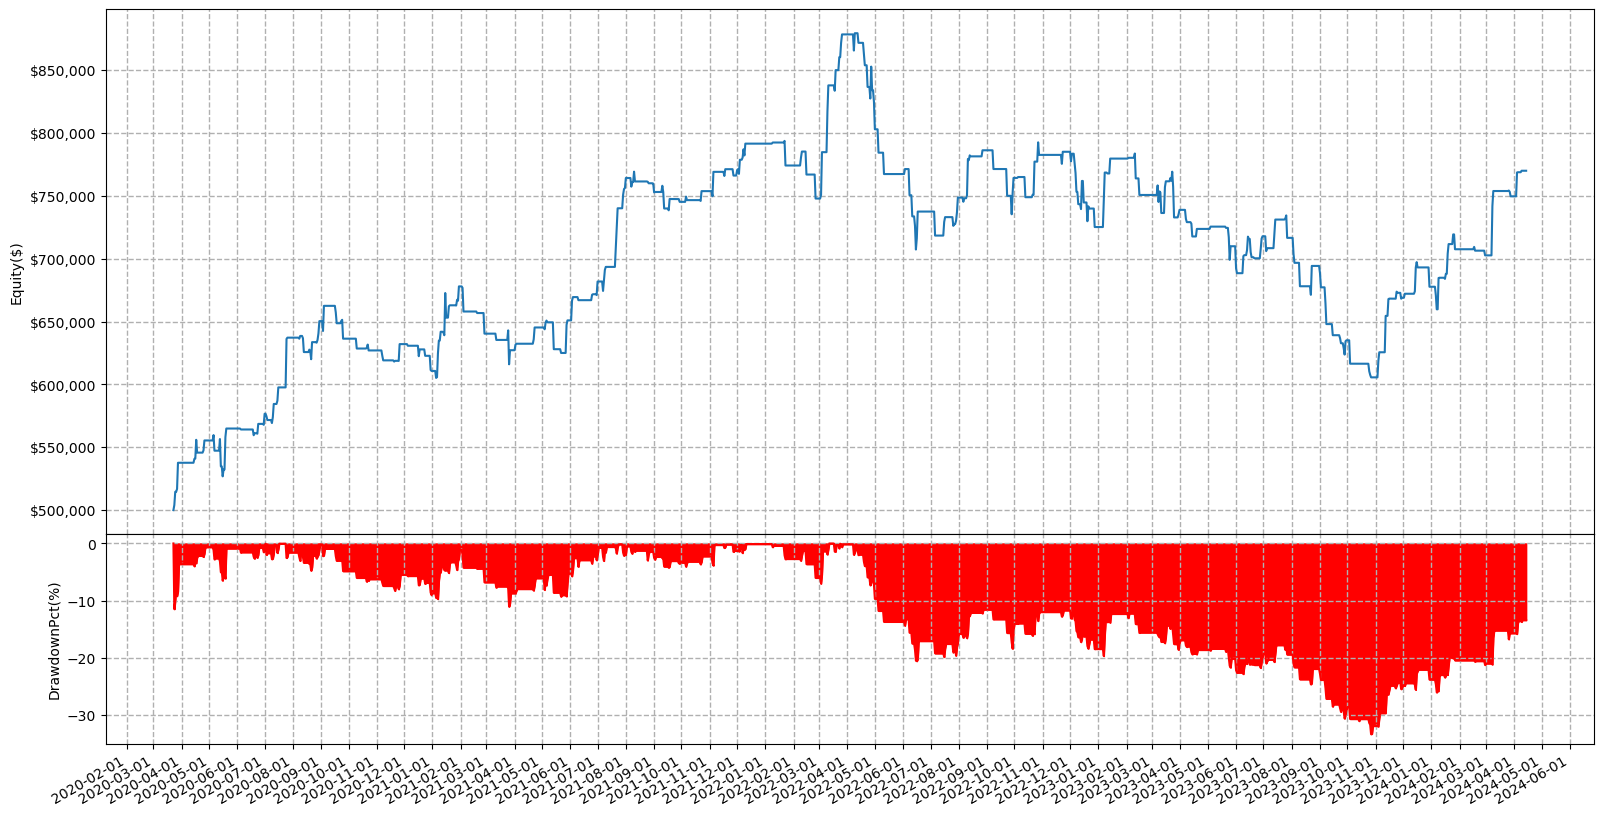

In [26]:
bt = Backtest(df, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
#Backtest(資料名稱, 策略名稱, cash=初始資金, commission=交易成本, hedging=是否優先對之前操作進行抵銷(競賽限定一次只能持有一口), exclusive_orders=每筆新交易是否關閉上一次的交易, margin=初始保證金比例)
stats = bt.run()
print(stats)
figure(stats)

  0%|          | 0/17 [00:00<?, ?it/s]

Start                     2020-03-22 08:50:00
End                       2022-12-31 23:55:00
Duration                   1014 days 15:05:00
Exposure Time [%]                    5.848201
Equity Final [$]                     744727.6
Equity Peak [$]                      967871.1
Return [%]                           48.94552
Buy & Hold Return [%]               55.860239
Return (Ann.) [%]                   15.404221
Volatility (Ann.) [%]               17.590503
Sharpe Ratio                         0.875712
Sortino Ratio                        1.700749
Calmar Ratio                         0.641574
Max. Drawdown [%]                  -24.010041
Avg. Drawdown [%]                    -0.89684
Max. Drawdown Duration      267 days 20:10:00
Avg. Drawdown Duration        5 days 18:36:00
# Trades                                  189
Win Rate [%]                        52.380952
Best Trade [%]                       1.748936
Worst Trade [%]                     -0.738211
Avg. Trade [%]                    

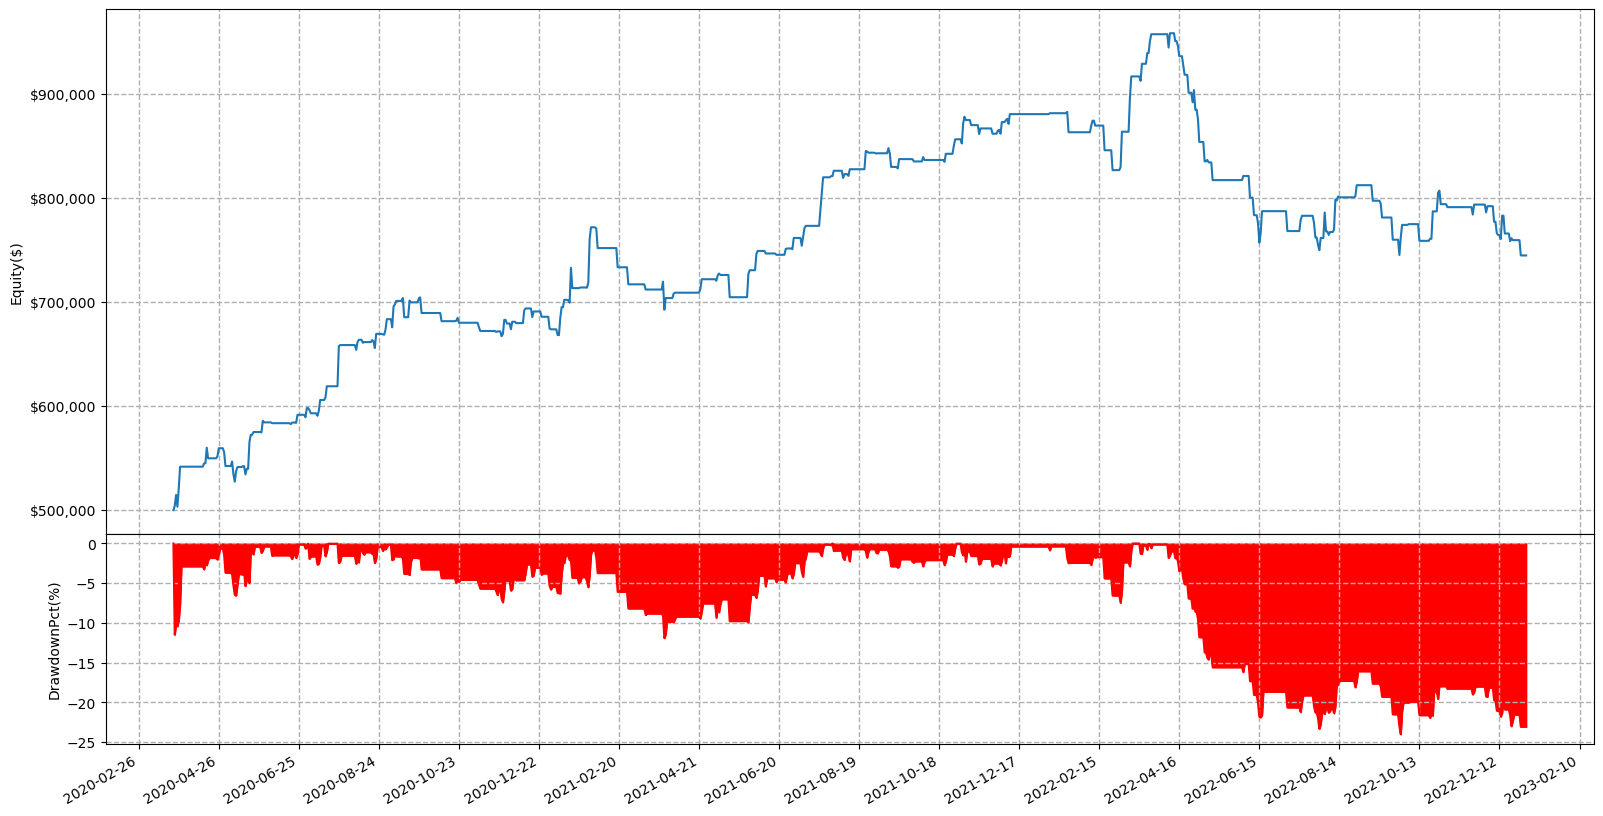

In [186]:
df_inner=df[df.index.year<2023] #樣本內2020-2022
bt_op = Backtest(df_inner, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
stats_op = bt_op.optimize(n_big_long=range(5,16,1), n_little_long=range(10,31,1))
print(stats_op)
print(stats_op['_strategy'])
figure(stats_op)

夜盤空單策略

In [27]:
class MyStrategy(Strategy):
    # Williams' %R
    wl_period = 3
    #EMA
    n_big_short = 13
    n_little_short = 24
    #止損
    stop_pct = 5   #表示0.5%

    def init(self):
        self.WILLR = self.I(ta.WILLR, self.data.High, self.data.Low, self.data.Close, timeperiod = self.wl_period)
        self.EMA_B = self.I(ta.EMA, self.data.大戶買進, timeperiod = self.n_big_short)
        self.EMA_L = self.I(ta.EMA, self.data.散戶買進, timeperiod = self.n_little_short)

    def next(self):
        current_time = self.data.index[-1].time()
        if (current_time >= time(15, 30) and current_time <= time(23, 59, 59)) or (current_time >= time(0, 0) and current_time <= time(4, 30)):
            if (not self.position.is_short):
                if self.WILLR[-1] < -80 and crossover(self.EMA_B, self.EMA_L):
                    self.sell(size=200)
            
            elif (self.position.is_short):    
                if self.WILLR[-1] > -20 and crossover(self.EMA_L, self.EMA_B):
                    self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
                        
        if self.position and (current_time >= time(4, 30) and current_time <= time(5, 00)):
            self.position.close()

Start                     2020-03-22 08:50:00
End                       2024-04-13 05:00:00
Duration                   1482 days 20:10:00
Exposure Time [%]                    3.244901
Equity Final [$]                     863632.4
Equity Peak [$]                      866232.4
Return [%]                           72.72648
Buy & Hold Return [%]              126.581159
Return (Ann.) [%]                   14.387892
Volatility (Ann.) [%]               18.360463
Sharpe Ratio                         0.783635
Sortino Ratio                        1.726883
Calmar Ratio                         0.748367
Max. Drawdown [%]                  -19.225729
Avg. Drawdown [%]                   -1.406668
Max. Drawdown Duration      464 days 04:00:00
Avg. Drawdown Duration       13 days 19:59:00
# Trades                                  150
Win Rate [%]                        44.666667
Best Trade [%]                        1.79331
Worst Trade [%]                     -0.668431
Avg. Trade [%]                    

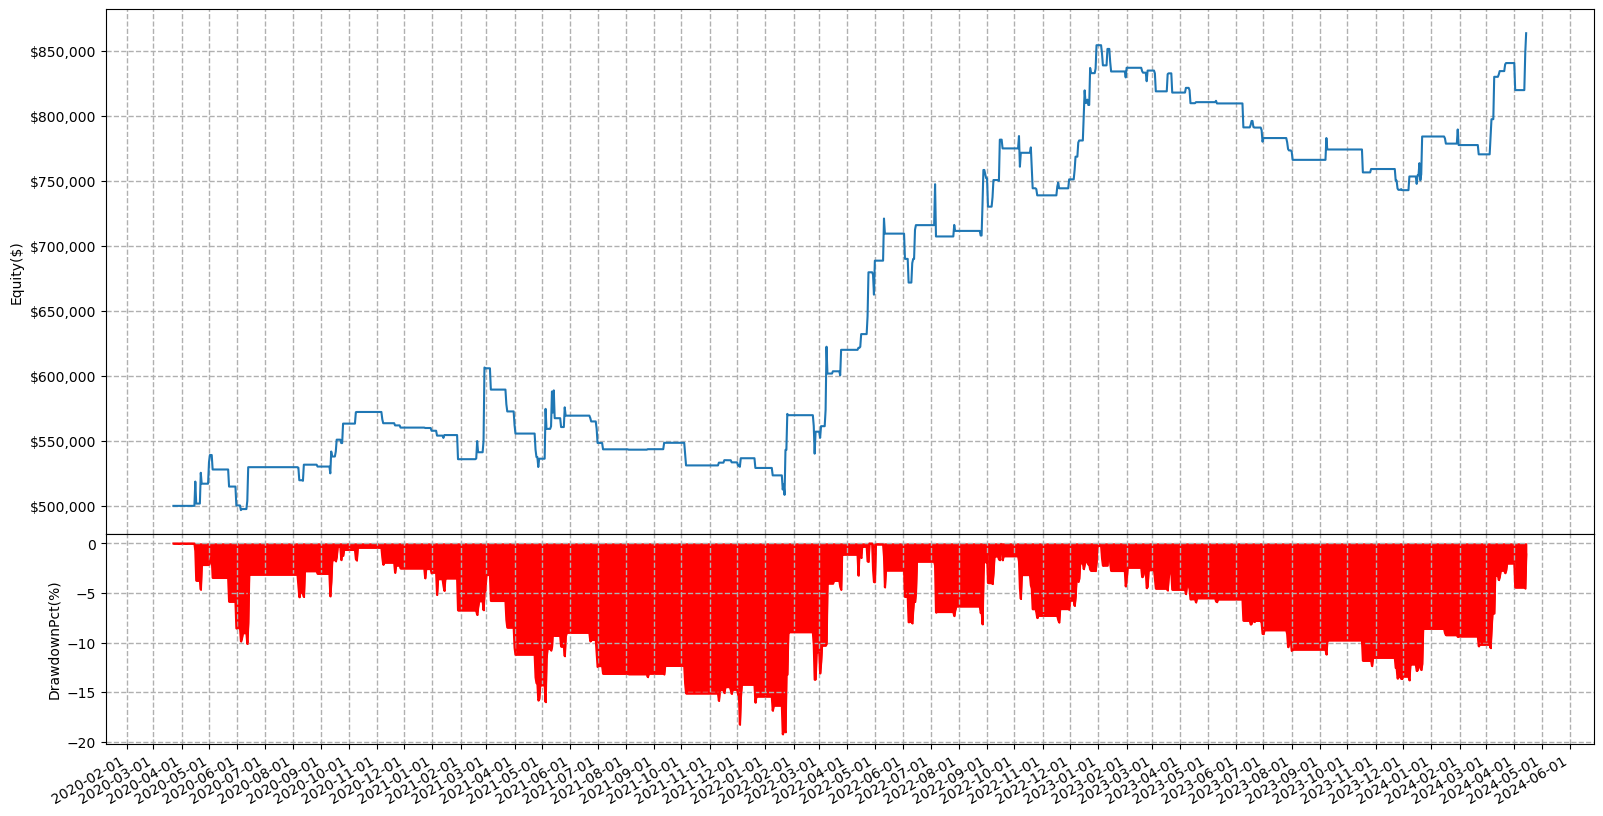

In [28]:
bt = Backtest(df, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
#Backtest(資料名稱, 策略名稱, cash=初始資金, commission=交易成本, hedging=是否優先對之前操作進行抵銷(競賽限定一次只能持有一口), exclusive_orders=每筆新交易是否關閉上一次的交易, margin=初始保證金比例)
stats = bt.run()
print(stats)
figure(stats)

c:\Users\vince\anaconda3\lib\site-packages\backtesting\backtesting.py:1488: UserWarning: Searching for best of 968 configurations.
  output = _optimize_grid()


  0%|          | 0/17 [00:00<?, ?it/s]

Start                     2020-03-22 08:50:00
End                       2022-12-31 23:55:00
Duration                   1014 days 15:05:00
Exposure Time [%]                    3.330077
Equity Final [$]                    854410.05
Equity Peak [$]                     856515.05
Return [%]                           70.88201
Buy & Hold Return [%]               55.860239
Return (Ann.) [%]                   21.249228
Volatility (Ann.) [%]               22.228651
Sharpe Ratio                         0.955939
Sortino Ratio                        2.287219
Calmar Ratio                          1.10525
Max. Drawdown [%]                  -19.225729
Avg. Drawdown [%]                   -1.344242
Max. Drawdown Duration      374 days 08:25:00
Avg. Drawdown Duration       10 days 01:02:00
# Trades                                  108
Win Rate [%]                        46.296296
Best Trade [%]                        1.79331
Worst Trade [%]                     -0.668431
Avg. Trade [%]                    

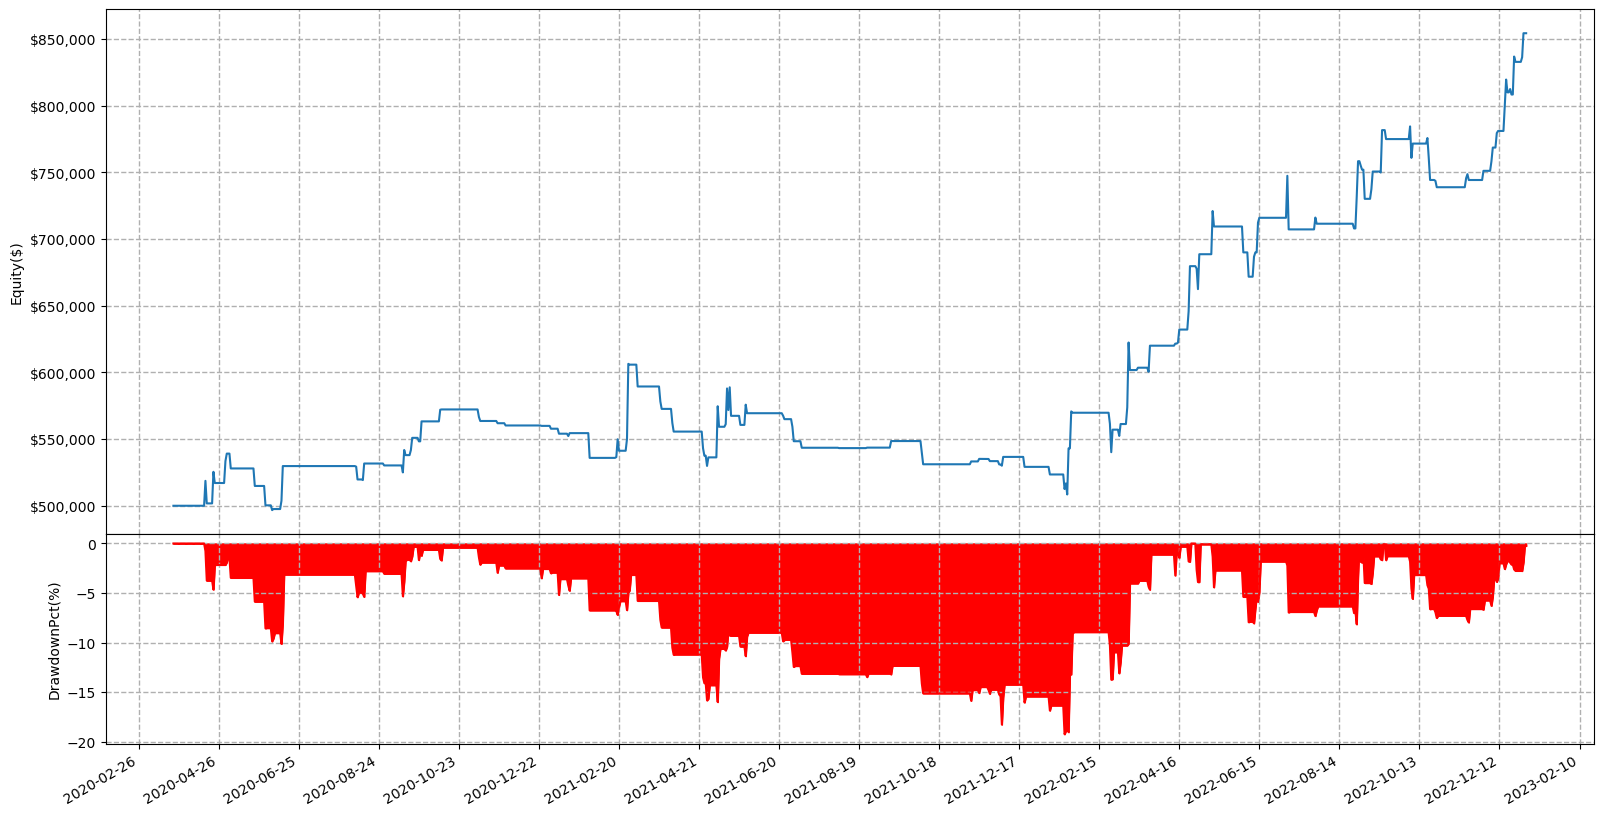

In [189]:
df_inner=df[df.index.year<2023] #樣本內2020-2022
bt_op = Backtest(df_inner, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
stats_op = bt_op.optimize(wl_period=range(3,11,1), n_big_short=range(5,16,1), n_little_short=range(15,26,1))
print(stats_op)
print(stats_op['_strategy'])
figure(stats_op)

日夜盤多空單

In [29]:
class MyStrategy(Strategy):
    #MACD
    fast = 5
    slow = 45
    signal = 35
    # Williams' %R
    wl_period = 3

    # EMA day long
    d_big_long = 5
    d_little_long = 15
    # EMA day short 
    d_big_short = 5
    d_little_short = 13
    # EMA night long
    n_big_long = 9
    n_little_long = 18
    # EMA nightt short
    n_big_short = 13
    n_little_short = 24

    #止損
    stop_pct = 5   #表示0.5%

    def init(self):
        self.WILLR = self.I(ta.WILLR, self.data.High, self.data.Low, self.data.Close, timeperiod = self.wl_period)

        self.macd, self.signal, self.hist = self.I(ta.MACD, self.data.Close, fastperiod=self.fast, slowperiod=self.slow, signalperiod=self.signal)
        self.EMA_DL_B=self.I(ta.EMA, self.data.大戶買進, timeperiod = self.d_big_long)
        self.EMA_DL_L=self.I(ta.EMA, self.data.散戶買進, timeperiod = self.d_little_long)
        
        self.EMA_DS_B = self.I(ta.EMA, self.data.大戶買進, timeperiod = self.d_big_short)
        self.EMA_DS_L = self.I(ta.EMA, self.data.散戶買進, timeperiod = self.d_little_short)

        self.EMA_NL_B=self.I(ta.EMA, self.data.大戶買進, timeperiod = self.n_big_long)
        self.EMA_NL_L=self.I(ta.EMA, self.data.散戶買進, timeperiod = self.n_little_long)
        
        self.EMA_NS_B = self.I(ta.EMA, self.data.大戶買進, timeperiod = self.n_big_short)
        self.EMA_NS_L = self.I(ta.EMA, self.data.散戶買進, timeperiod = self.n_little_short)
    def next(self):
        current_time = self.data.index[-1].time()
        # 日盤
        if (current_time >= time(9, 15)) and (current_time <= time(13, 15)):
            if (not self.position.is_long) and (not self.position.is_short):
                # 日盤多單進場
                if self.hist[-1] > 0 and crossover(self.EMA_DL_L, self.EMA_DL_B):
                    self.buy(size=200)
                # 日盤空單進場
                elif self.WILLR[-1] < -80 and crossover(self.EMA_DS_B, self.EMA_DS_L):
                    self.sell(size=200)
            # 日盤多單出場
            elif (self.position.is_long):    
                if self.hist[-1] < 0 and crossover(self.EMA_DL_B, self.EMA_DL_L):
                    self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
            # 日盤空單出場
            elif (self.position.is_short):    
                if crossover(self.EMA_DS_L, self.EMA_DS_B):
                    self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
        # 夜盤
        if (current_time >= time(15, 30) and current_time <= time(23, 59, 59)) or (current_time >= time(0, 0) and current_time <= time(4, 30)):
            if (not self.position.is_long) and (not self.position.is_short):
                # 夜盤多單進場
                if self.hist[-1] > 0 and crossover(self.EMA_NL_B, self.EMA_NL_L):
                    self.buy(size=200)
                # 夜盤空單進場
                elif self.WILLR[-1] < -80 and crossover(self.EMA_NS_B, self.EMA_NS_L):
                    self.sell(size=200)
            # 夜盤多單出場
            elif (self.position.is_long):    
                if self.hist[-1] < 0 and crossover(self.EMA_NL_L, self.EMA_NL_B):
                    self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()
            # 夜盤空單出場
            elif (self.position.is_short):    
                if self.WILLR[-1] > -20 and crossover(self.EMA_NS_L, self.EMA_NS_B):
                    self.position.close()
                elif self.position.pl_pct < -(self.stop_pct * 0.001):
                    self.position.close()

        if self.position and ((current_time >= time(13, 15) and current_time < time(13, 45)) or (current_time >= time(4, 30) and current_time <= time(5, 00))):
            self.position.close()

Start                     2020-03-22 08:50:00
End                       2024-04-13 05:00:00
Duration                   1482 days 20:10:00
Exposure Time [%]                    9.950189
Equity Final [$]                   1478715.15
Equity Peak [$]                    1481315.15
Return [%]                          195.74303
Buy & Hold Return [%]              126.581159
Return (Ann.) [%]                   30.564365
Volatility (Ann.) [%]               23.929439
Sharpe Ratio                          1.27727
Sortino Ratio                        2.946145
Calmar Ratio                         1.542332
Max. Drawdown [%]                  -19.816987
Avg. Drawdown [%]                   -1.066582
Max. Drawdown Duration      463 days 14:25:00
Avg. Drawdown Duration        5 days 01:47:00
# Trades                                  653
Win Rate [%]                         49.92343
Best Trade [%]                       2.048571
Worst Trade [%]                     -0.962727
Avg. Trade [%]                    

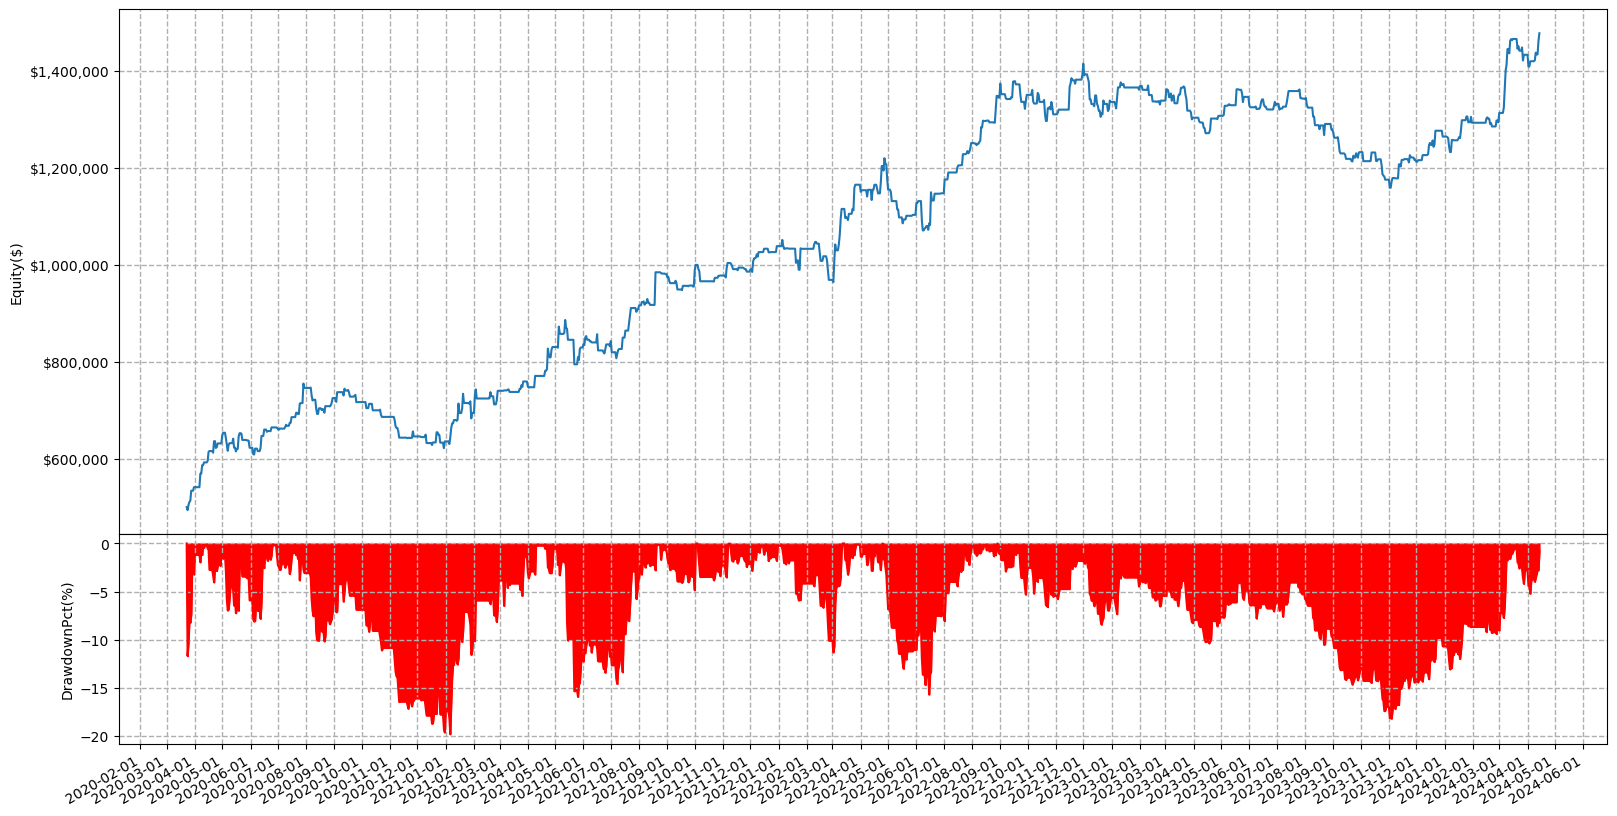

In [30]:
bt = Backtest(df, MyStrategy, cash=500000, commission=0.00025, hedging=False, exclusive_orders=False, margin=0.05)
#Backtest(資料名稱, 策略名稱, cash=初始資金, commission=交易成本, hedging=是否優先對之前操作進行抵銷(競賽限定一次只能持有一口), exclusive_orders=每筆新交易是否關閉上一次的交易, margin=初始保證金比例)
stats = bt.run()
print(stats)
figure(stats)